In [ ]:
# Cài đặt thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Tải dữ liệu từ Kaggle
!pip install kaggle

# Tạo thư mục cho kaggle API
!mkdir -p ~/.kaggle

# Tạo file kaggle.json với thông tin tài khoản Kaggle của bạn
!echo '{"username":"","key":""}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p data

# Tải và giải nén plant-doc-dataset
!kaggle datasets download -d abdulhasibuddin/plant-doc-dataset
!unzip -o plant-doc-dataset.zip -d data/plant-doc

# Tải và giải nén plantvillage-dataset
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -o plantvillage-dataset.zip -d data/plantvillage


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: data/plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e345153-aed9-4879-a2cc-24f9dc5100e7___UF.GRC_YLCV_Lab 01798_final_masked.jpg  
  inflating: data/plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e37e8ad-3944-4e11-bc10-dd82616274d7___YLCV_NREC 2915_final_masked.jpg  
  inflating: data/plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e382244-fb3a-4caa-af71-05fff25f1c27___UF.GRC_YLCV_Lab 03397_final_masked.jpg  
  inflating: data/plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e3b9886-ce13-49d5-8f80-ccf4e5ddbeac___YLCV_GCREC 5479_final_masked.jpg  
  inflating: data/plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e615038-7a87-446a-a2cd-f76c5c75b6dd___YLCV_GCREC 5144_final_masked.jpg  
  inflating: data/plantvillage/plantvillage dataset/segme


 Phân tích dataset: PlantVillage (color)
Số lượng lớp: 38
Các lớp bệnh: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_sp

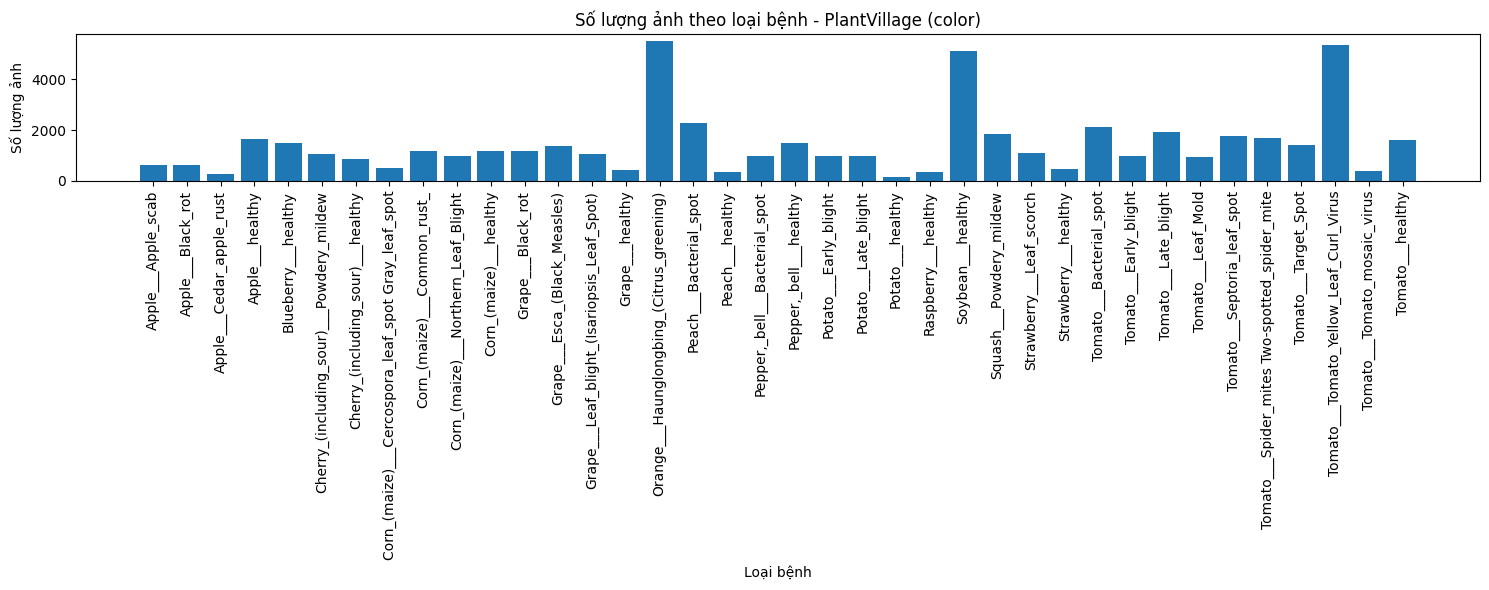


 Phân tích dataset: PlantDoc (train)
Số lượng lớp: 27
Các lớp bệnh: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Raspberry leaf', 'Soyabean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'grape leaf', 'grape leaf black rot']


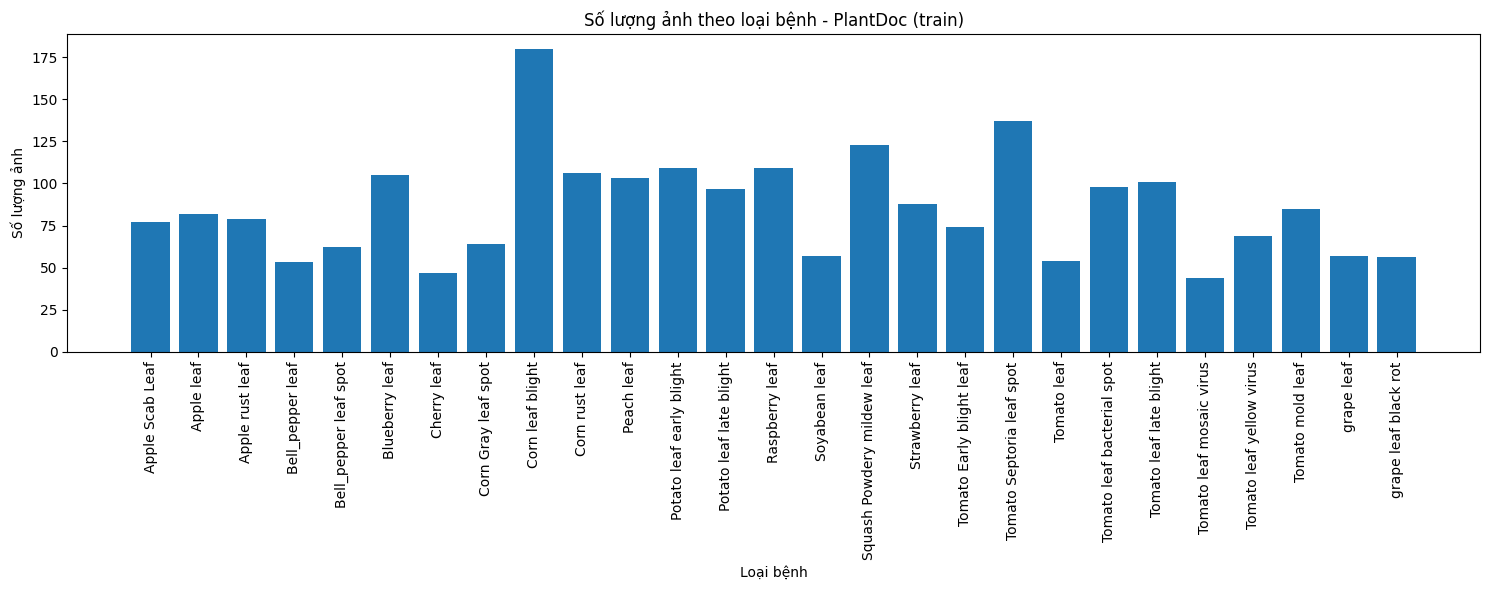


 Phân tích dataset: PlantDoc (test)
Số lượng lớp: 27
Các lớp bệnh: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Raspberry leaf', 'Soyabean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'grape leaf', 'grape leaf black rot']


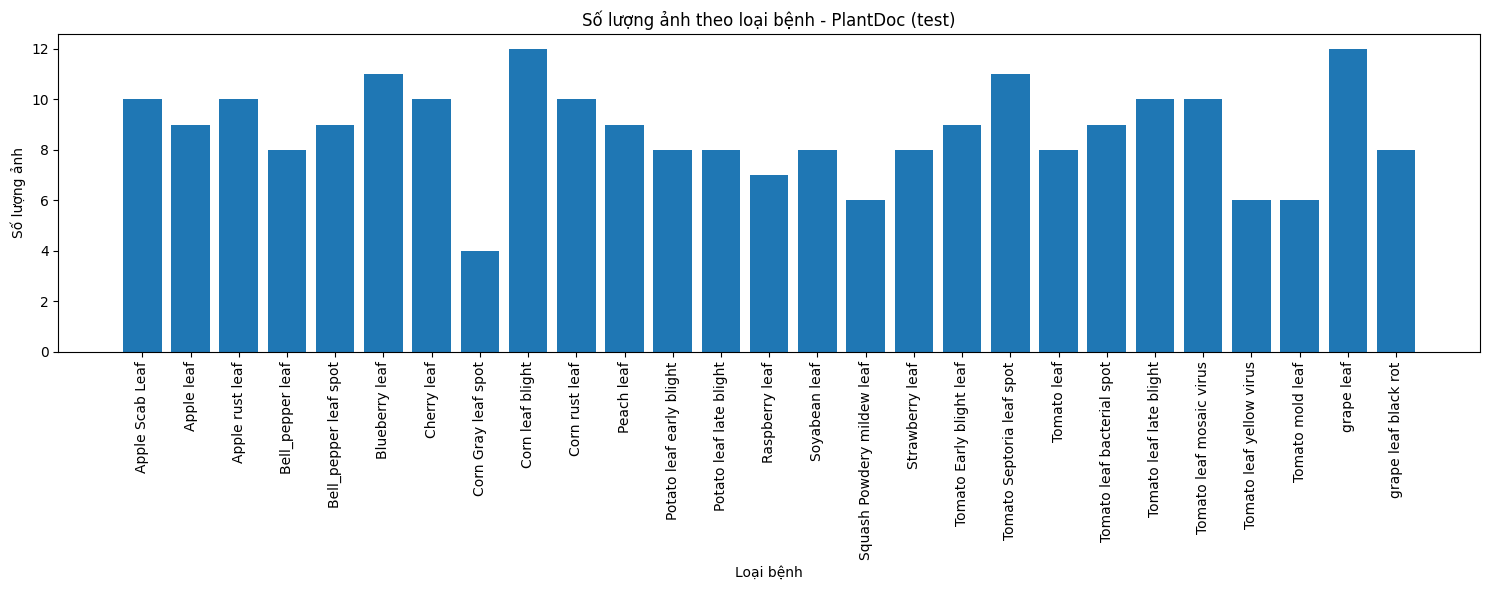

In [ ]:
import os
import matplotlib.pyplot as plt

def analyze_dataset(title, data_path):
    print(f"\n Phân tích dataset: {title}")
    classes = sorted(os.listdir(data_path))
    print(f"Số lượng lớp: {len(classes)}")
    print(f"Các lớp bệnh: {classes}")

    counts = {}
    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        if os.path.isdir(cls_path):  # tránh lỗi nếu có file lẻ
            counts[cls] = len(os.listdir(cls_path))

    # Vẽ biểu đồ
    plt.figure(figsize=(15, 6))
    plt.bar(counts.keys(), counts.values())
    plt.xticks(rotation=90)
    plt.title(f'Số lượng ảnh theo loại bệnh - {title}')
    plt.xlabel('Loại bệnh')
    plt.ylabel('Số lượng ảnh')
    plt.tight_layout()
    plt.show()

# Kiểm tra PlantVillage dataset (thư mục color)
analyze_dataset("PlantVillage (color)", "/content/data/plantvillage/plantvillage dataset/color")

# Kiểm tra PlantDoc dataset (train)
analyze_dataset("PlantDoc (train)", "/content/data/plant-doc/PlantDoc-Dataset/train")

# Kiểm tra PlantDoc dataset (test)
analyze_dataset("PlantDoc (test)", "/content/data/plant-doc/PlantDoc-Dataset/test")


In [ ]:
label_mapping = {
    "Apple Scab Leaf": "Apple___Apple_scab",
    "Apple rust leaf": "Apple___Cedar_apple_rust",
    "Apple leaf": "Apple___healthy",
    "Bell_pepper leaf": "Pepper,_bell___healthy",
    "Bell_pepper leaf spot": "Pepper,_bell___Bacterial_spot",
    "Blueberry leaf": "Blueberry___healthy",
    "Cherry leaf": "Cherry_(including_sour)___healthy",
    "Corn rust leaf": "Corn_(maize)___Common_rust_",
    "Corn leaf blight": "Corn_(maize)___Northern_Leaf_Blight",
    "Corn Gray leaf spot": "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Peach leaf": "Peach___healthy",
    "Potato leaf early blight": "Potato___Early_blight",
    "Potato leaf late blight": "Potato___Late_blight",
    "Raspberry leaf": "Raspberry___healthy",
    "Soyabean leaf": "Soybean___healthy",
    "Squash Powdery mildew leaf": "Squash___Powdery_mildew",
    "Strawberry leaf": "Strawberry___healthy",
    "Tomato Early blight leaf": "Tomato___Early_blight",
    "Tomato Septoria leaf spot": "Tomato___Septoria_leaf_spot",
    "Tomato leaf": "Tomato___healthy",
    "Tomato leaf bacterial spot": "Tomato___Bacterial_spot",
    "Tomato leaf late blight": "Tomato___Late_blight",
    "Tomato leaf mosaic virus": "Tomato___Tomato_mosaic_virus",
    "Tomato leaf yellow virus": "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato mold leaf": "Tomato___Leaf_Mold",
    "grape leaf": "Grape___healthy",
    "grape leaf black rot": "Grape___Black_rot"
}


In [ ]:
import os
import shutil

def rename_labels(data_root, label_mapping):
    for old_name, new_name in label_mapping.items():
        old_path = os.path.join(data_root, old_name)
        new_path = os.path.join(data_root, new_name)
        if os.path.exists(old_path):
            if not os.path.exists(new_path):
                shutil.move(old_path, new_path)
                print(f" Đổi: {old_name} ➜ {new_name}")
            else:
                print(f" Bỏ qua: {new_name} đã tồn tại")
        else:
            print(f" Không tìm thấy: {old_name}")

# Đường dẫn đến train & test của PlantDoc
train_path = "/content/data/plant-doc/PlantDoc-Dataset/train"
test_path = "/content/data/plant-doc/PlantDoc-Dataset/test"

# Thực hiện đổi tên
rename_labels(train_path, label_mapping)
rename_labels(test_path, label_mapping)


 Đổi: Apple Scab Leaf ➜ Apple___Apple_scab
 Đổi: Apple rust leaf ➜ Apple___Cedar_apple_rust
 Đổi: Apple leaf ➜ Apple___healthy
 Đổi: Bell_pepper leaf ➜ Pepper,_bell___healthy
 Đổi: Bell_pepper leaf spot ➜ Pepper,_bell___Bacterial_spot
 Đổi: Blueberry leaf ➜ Blueberry___healthy
 Đổi: Cherry leaf ➜ Cherry_(including_sour)___healthy
 Đổi: Corn rust leaf ➜ Corn_(maize)___Common_rust_
 Đổi: Corn leaf blight ➜ Corn_(maize)___Northern_Leaf_Blight
 Đổi: Corn Gray leaf spot ➜ Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 Đổi: Peach leaf ➜ Peach___healthy
 Đổi: Potato leaf early blight ➜ Potato___Early_blight
 Đổi: Potato leaf late blight ➜ Potato___Late_blight
 Đổi: Raspberry leaf ➜ Raspberry___healthy
 Đổi: Soyabean leaf ➜ Soybean___healthy
 Đổi: Squash Powdery mildew leaf ➜ Squash___Powdery_mildew
 Đổi: Strawberry leaf ➜ Strawberry___healthy
 Đổi: Tomato Early blight leaf ➜ Tomato___Early_blight
 Đổi: Tomato Septoria leaf spot ➜ Tomato___Septoria_leaf_spot
 Đổi: Tomato leaf ➜ Tomato___h

In [ ]:
import os
import shutil
from tqdm import tqdm

def merge_datasets(sources, dest_root):
    os.makedirs(dest_root, exist_ok=True)
    for src in sources:
        for cls_name in os.listdir(src):
            src_cls_path = os.path.join(src, cls_name)
            dst_cls_path = os.path.join(dest_root, cls_name)
            os.makedirs(dst_cls_path, exist_ok=True)
            for img in os.listdir(src_cls_path):
                src_img_path = os.path.join(src_cls_path, img)
                dst_img_path = os.path.join(dst_cls_path, img)
                # Tránh ghi đè file
                if not os.path.exists(dst_img_path):
                    shutil.copy(src_img_path, dst_img_path)

# Nguồn
village_dir = '/content/data/plantvillage/plantvillage dataset/color'
doc_train_dir = '/content/data/plant-doc/PlantDoc-Dataset/train'
#doc_test_dir = '/content/data/plant-doc/PlantDoc-Dataset/test'

# Đích
merged_dir = '/content/data/merged_dataset'

# Gộp dữ liệu
merge_datasets([village_dir, doc_train_dir], merged_dir)
print(" Đã gộp toàn bộ dữ liệu vào thư mục `merged_dataset/`")


 Đã gộp toàn bộ dữ liệu vào thư mục `merged_dataset/`


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Giả sử merged_dir chứa các thư mục con tên là tên lớp
class_names = sorted(os.listdir(merged_dir))  # Lấy danh sách tên lớp theo thứ tự alphabet
label_encoder = LabelEncoder()
label_encoder.fit(class_names)

# Tạo ánh xạ index -> tên lớp
class_indices_dict = dict(enumerate(label_encoder.classes_))


In [ ]:
import json

# Đường dẫn lưu file ánh xạ
mapping_file = '/content/class_indices_moi.json'

# Lưu ánh xạ class index -> class name vào file JSON
with open(mapping_file, 'w') as f:
    json.dump(class_indices_dict, f, indent=4)

print(f"Đã lưu ánh xạ class index vào: {mapping_file}")


Đã lưu ánh xạ class index vào: /content/class_indices_moi.json


In [ ]:
from google.colab import files

files.download('/content/class_indices_moi.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tổng số lớp sau khi gộp: 38


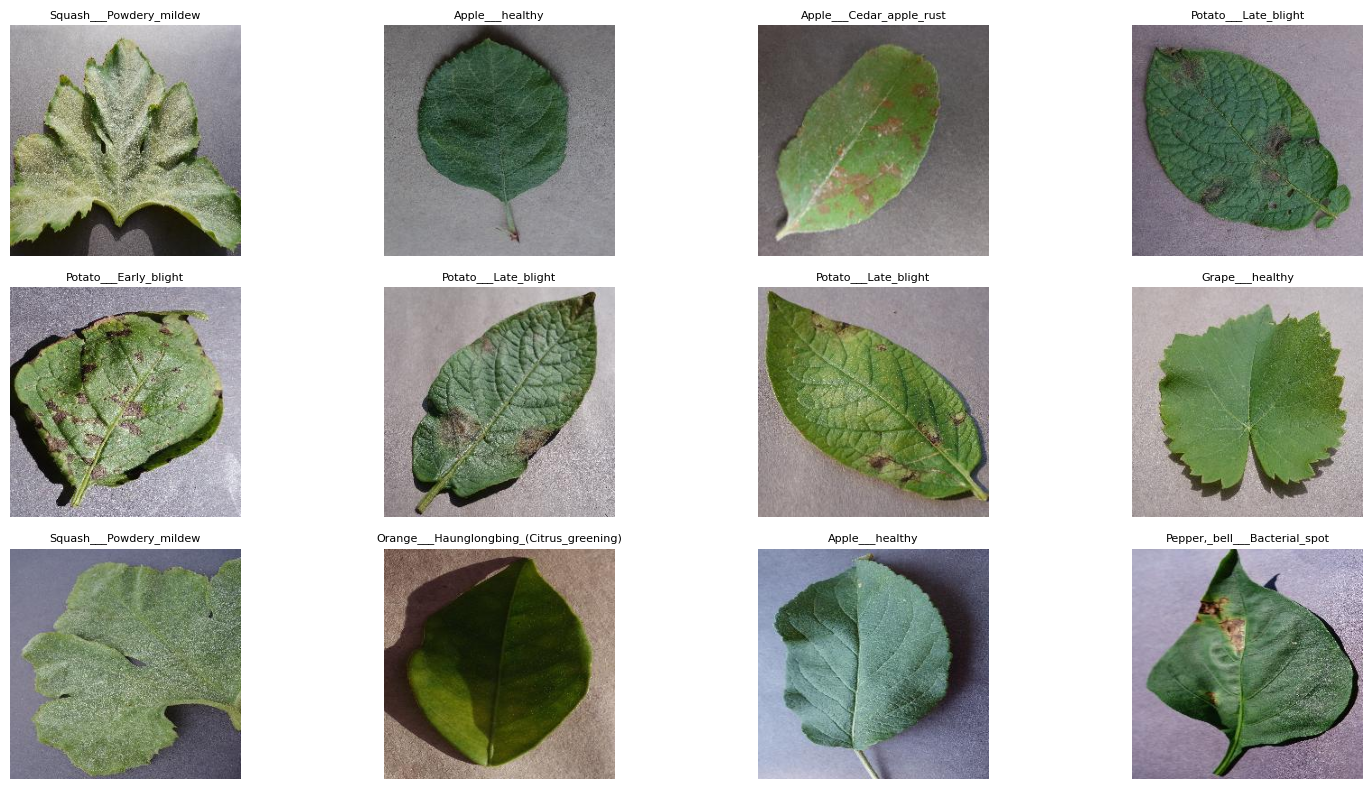

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image

# Đường dẫn đến tập dữ liệu đã gộp
data_dir = merged_dir
classes = os.listdir(data_dir)
print(f"Tổng số lớp sau khi gộp: {len(classes)}")

# Hiển thị một vài ảnh ngẫu nhiên
def show_random_images(data_dir, classes, num_images=12):
    plt.figure(figsize=(16, 8))
    for i in range(num_images):
        cls = random.choice(classes)
        cls_path = os.path.join(data_dir, cls)
        img_name = random.choice(os.listdir(cls_path))
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.title(cls, fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_random_images(data_dir, classes)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Thiết lập kích thước ảnh và batch size giống bài mẫu
IMG_SIZE = 224  # dành cho MobileNet
BATCH_SIZE = 64

# Đường dẫn đến thư mục dữ liệu đã gộp
data_dir = '/content/data/merged_dataset'  # đã gộp từ PlantVillage và PlantDoc

# Tạo ImageDataGenerator cho train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ImageDataGenerator cho validation
valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Tạo train generator
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Tạo validation generator
validation_generator = valid_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Lưu lại thông tin các lớp
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())
num_classes = len(class_names)

print(f"Số lượng lớp: {num_classes}")
print(f"Số lượng ảnh huấn luyện: {train_generator.samples}")
print(f"Số lượng ảnh kiểm định: {validation_generator.samples}")


Found 45312 images belonging to 38 classes.
Found 11309 images belonging to 38 classes.
Số lượng lớp: 38
Số lượng ảnh huấn luyện: 45312
Số lượng ảnh kiểm định: 11309


In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Tạo thư mục để lưu mô hình và lịch sử huấn luyện
drive_path = '/content/drive/MyDrive/PlantDiseaseModel_moi'
os.makedirs(drive_path, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 64
data_dir = '/content/data/merged_dataset'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = valid_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Lưu lại thông tin các lớp
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())
num_classes = len(class_names)

print(f"Số lượng lớp: {num_classes}")
print(f"Số lượng ảnh huấn luyện: {train_generator.samples}")
print(f"Số lượng ảnh kiểm định: {validation_generator.samples}")


Found 45312 images belonging to 38 classes.
Found 11309 images belonging to 38 classes.
Số lượng lớp: 38
Số lượng ảnh huấn luyện: 45312
Số lượng ảnh kiểm định: 11309


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,054,950 (11.65 MB)

 Trainable params: 796,966 (3.04 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import json
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau

class CustomModelCheckpoint(Callback):
    def __init__(self, save_dir):
        super().__init__()
        self.save_dir = save_dir

    def on_epoch_end(self, epoch, logs=None):
        model_path = os.path.join(self.save_dir, f'model_epoch_{epoch+1:02d}.h5')
        self.model.save(model_path)
        print(f'\n Saved model to: {model_path}')

class SaveHistoryToDrive(Callback):
    def __init__(self, filepath):
        super().__init__()
        self.filepath = filepath
        self.history_data = []

    def on_epoch_end(self, epoch, logs=None):
        self.history_data.append(logs)
        with open(self.filepath, 'w') as f:
            json.dump(self.history_data, f, indent=4)
        print(f' History saved to {self.filepath}')


In [ ]:
import json
from tensorflow.keras.callbacks import LambdaCallback
checkpoint_callback = CustomModelCheckpoint(drive_path)
history_callback = SaveHistoryToDrive(os.path.join(drive_path, 'training_history.json'))

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

callbacks = [checkpoint_callback, history_callback, early_stopping, reduce_lr]
epochs = 15
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=epochs,
    callbacks=callbacks
)



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.5976 - loss: 1.4775


 Saved model to: /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_01.h5
 History saved to /content/drive/MyDrive/PlantDiseaseModel_moi/training_history.json
708/708 ━━━━━━━━━━━━━━━━━━━━ 626s 864ms/step - accuracy: 0.5977 - loss: 1.4768 - val_accuracy: 0.8737 - val_loss: 0.3875 - learning_rate: 0.0010
Epoch 2/15
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.8113 - loss: 0.6032


 Saved model to: /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_02.h5
 History saved to /content/drive/MyDrive/PlantDiseaseModel_moi/training_history.json
708/708 ━━━━━━━━━━━━━━━━━━━━ 600s 847ms/step - accuracy: 0.8113 - loss: 0.6032 - val_accuracy: 0.9021 - val_loss: 0.3214 - learning_rate: 0.0010
Epoch 3/15
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.8408 - loss: 0.5177


 Saved model to: /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_03.h5
 History saved to /content/drive/MyDrive/PlantDiseaseModel_moi/training_history.json
708/708 ━━━━━━━━━━━━━━━━━━━━ 682s 932ms/step - accuracy: 0.8408 - loss: 0.5177 - val_accuracy: 0.9094 - val_loss: 0.2911 - learning_rate: 0.0010
Epoch 4/15
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.8531 - loss: 0.4741

...


 Saved model to: /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_11.h5
 History saved to /content/drive/MyDrive/PlantDiseaseModel_moi/training_history.json
708/708 ━━━━━━━━━━━━━━━━━━━━ 603s 852ms/step - accuracy: 0.9070 - loss: 0.2890 - val_accuracy: 0.9362 - val_loss: 0.2135 - learning_rate: 2.5000e-04
Epoch 12/15
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.9100 - loss: 0.2855


 Saved model to: /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_12.h5
 History saved to /content/drive/MyDrive/PlantDiseaseModel_moi/training_history.json
708/708 ━━━━━━━━━━━━━━━━━━━━ 602s 850ms/step - accuracy: 0.9100 - loss: 0.2855 - val_accuracy: 0.9363 - val_loss: 0.2124 - learning_rate: 2.5000e-04
Epoch 13/15
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9139 - loss: 0.2705


 Saved model to: /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_13.h5
 History saved to /content/drive/MyDrive/PlantDiseaseModel_moi/training_history.json
708/708 ━━━━━━━━━━━━━━━━━━━━ 592s 836ms/step - accuracy: 0.9138 - loss: 0.2705 - val_accuracy: 0.9353 - val_loss: 0.2174 - learning_rate: 2.5000e-04
Epoch 14/15
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.9147 - loss: 0.2638


 Saved model to: /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_14.h5
 History saved to /content/drive/MyDrive/PlantDiseaseModel_moi/training_history.json

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
708/708 ━━━━━━━━━━━━━━━━━━━━ 632s 850ms/step - accuracy: 0.9147 - loss: 0.2638 - val_accuracy: 0.9371 - val_loss: 0.2124 - learning_rate: 2.5000e-04
Epoch 15/15
708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.9174 - loss: 0.2525


 Saved model to: /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_15.h5
 History saved to /content/drive/MyDrive/PlantDiseaseModel_moi/training_history.json
708/708 ━━━━━━━━━━━━━━━━━━━━ 622s 850ms/step - accuracy: 0.9174 - loss: 0.2525 - val_accuracy: 0.9402 - val_loss: 0.2043 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 15.


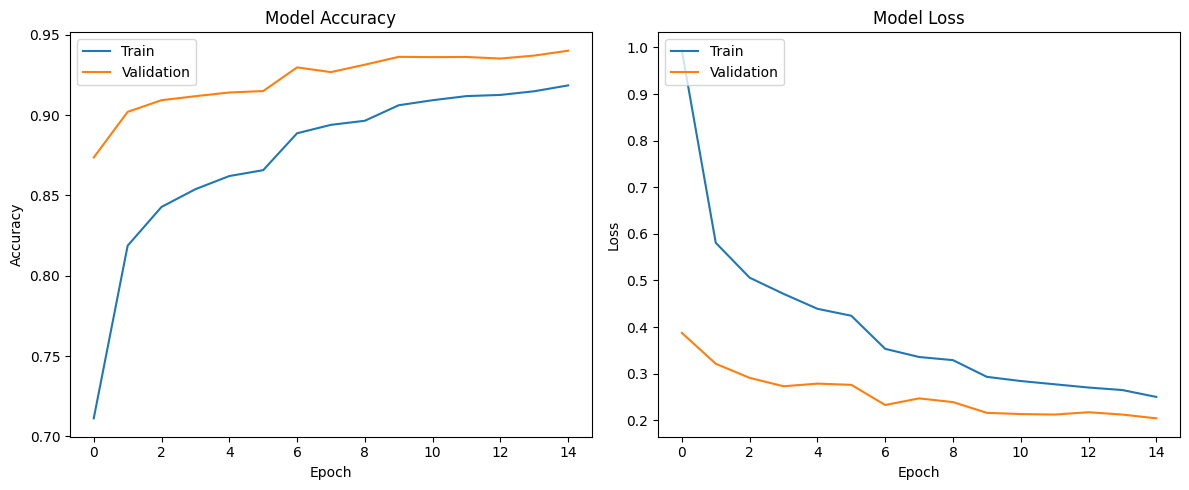

In [ ]:
# Vẽ biểu đồ loss và accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

177/177 ━━━━━━━━━━━━━━━━━━━━ 34s 174ms/step
Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.91      0.95       141
                                 Apple___Black_rot       0.99      0.98      0.98       124
                          Apple___Cedar_apple_rust       0.96      0.97      0.96        70
                                   Apple___healthy       0.99      0.97      0.98       345
                               Blueberry___healthy       1.00      0.98      0.99       321
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       210
                 Cherry_(including_sour)___healthy       0.97      0.98      0.98       180
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.60      0.84      0.70       115
                       Corn_(maize)___Common_rust_       0.99      0.61      0.75       259
            

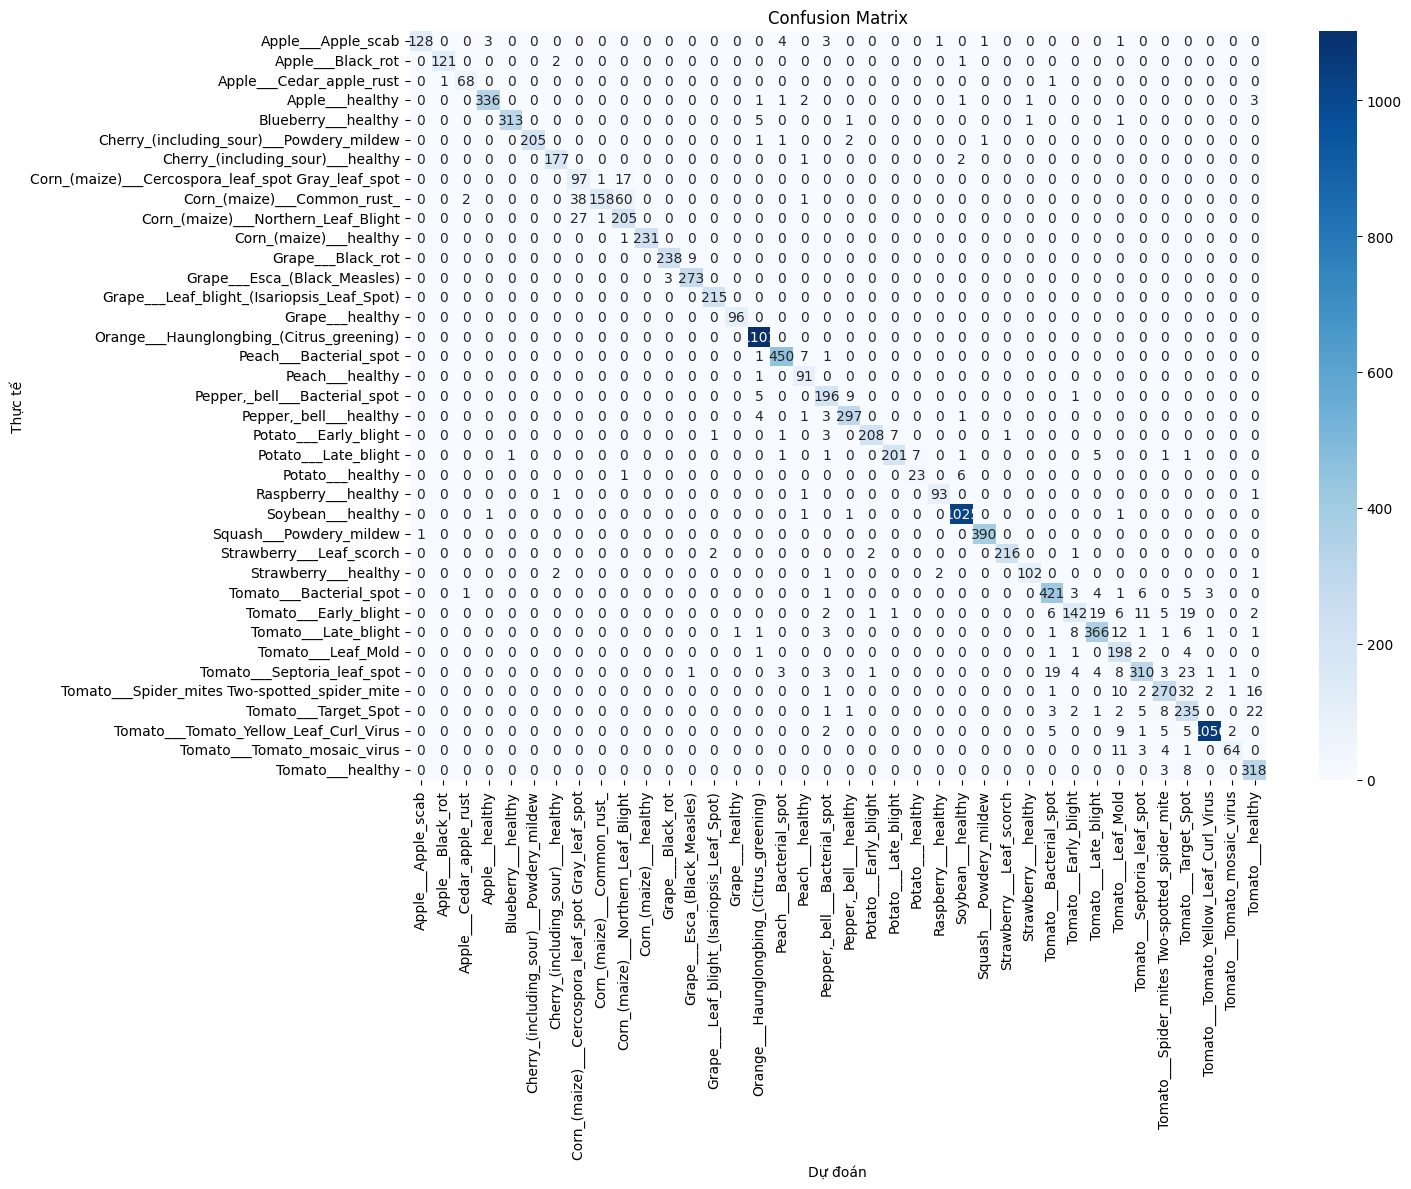

In [ ]:
# Dự đoán trên tập validation
validation_generator.reset()
Y_pred = model.predict(validation_generator, validation_generator.samples // BATCH_SIZE + 1)
y_pred = np.argmax(Y_pred, axis=1)

# Lấy nhãn thực tế
y_true = validation_generator.classes

# In báo cáo phân loại
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Tạo confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

Test model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix
import json

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


load model và class mapping

In [ ]:
# Đường dẫn tới model và file mapping trên Google Drive
drive_path = '/content/drive/MyDrive/PlantDiseaseModel_moi'
model_file = 'model_epoch_15.h5'  # Đổi tên nếu cần
model_path = os.path.join(drive_path, model_file)

# Load model
model = load_model(model_path)
print(f"Loaded model from {model_path}")

# Load class mapping
with open('/content/class_indices_moi.json', 'r') as f:
    class_indices = json.load(f)
class_names = [class_indices[str(i)] for i in range(len(class_indices))]
print("Loaded class mapping.")


Loaded model from /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_15.h5
Loaded class mapping.


đánh giá trên tập validation hoặc mẫu ngẫu nhiên

Found 11309 images belonging to 38 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


177/177 ━━━━━━━━━━━━━━━━━━━━ 583s 3s/step - accuracy: 0.9457 - loss: 0.2097
Validation Accuracy: 94.03%
177/177 ━━━━━━━━━━━━━━━━━━━━ 579s 3s/step
Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.91      0.95       141
                                 Apple___Black_rot       0.99      0.98      0.98       124
                          Apple___Cedar_apple_rust       0.96      0.97      0.96        70
                                   Apple___healthy       0.99      0.97      0.98       345
                               Blueberry___healthy       1.00      0.98      0.99       321
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       210
                 Cherry_(including_sour)___healthy       0.97      0.98      0.98       180
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.60      0.84      0.70       115
  

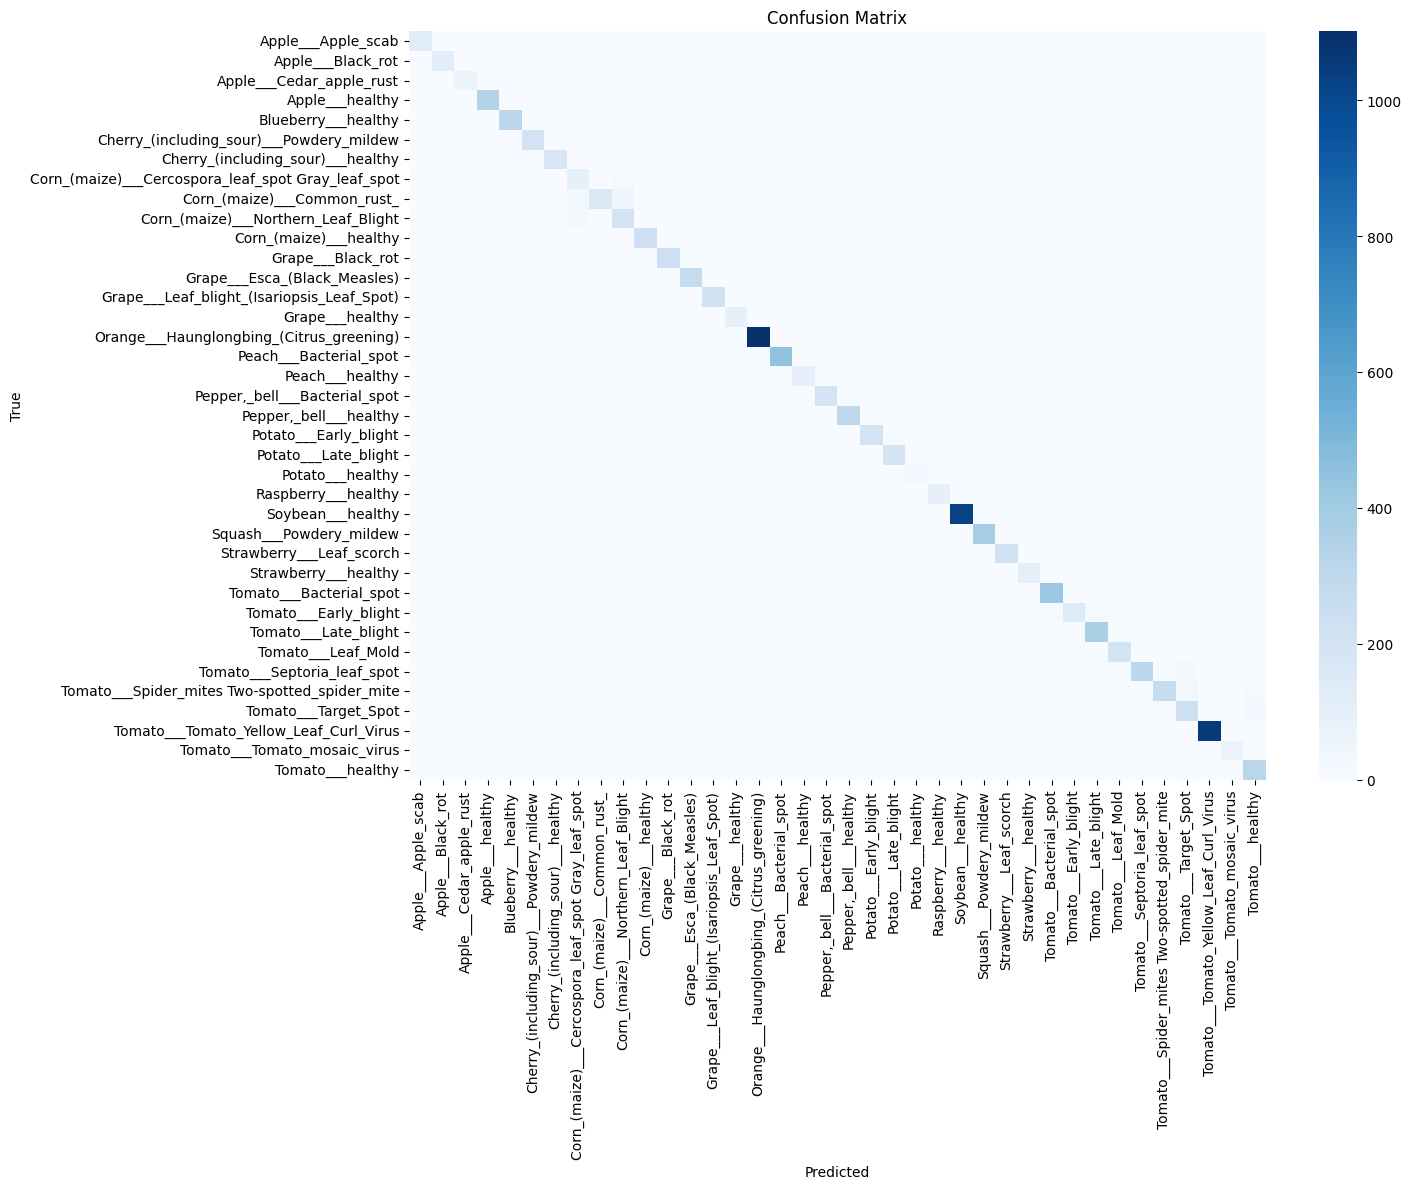

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
data_dir = '/content/data/merged_dataset'

# Tạo generator cho validation
valid_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
validation_generator = valid_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Đánh giá model trên toàn bộ tập validation
val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
print(f'Validation Accuracy: {val_acc*100:.2f}%')

# Dự đoán và báo cáo phân loại
validation_generator.reset()
Y_pred = model.predict(validation_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


Nếu muốn test trên một số mẫu ngẫu nhiên từ validation

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


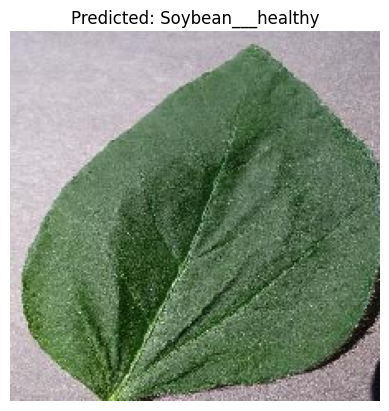

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


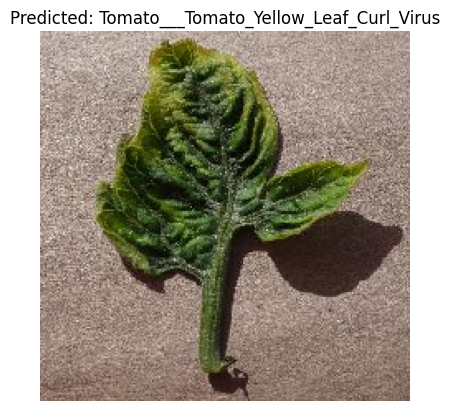

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


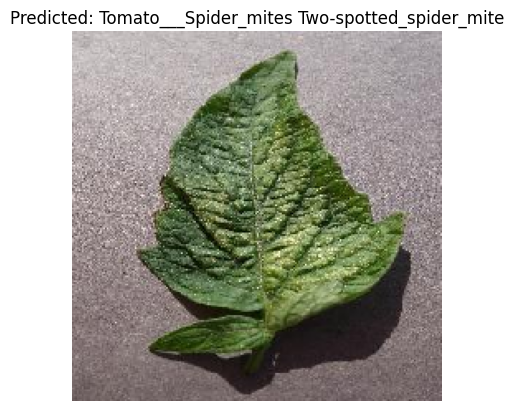

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


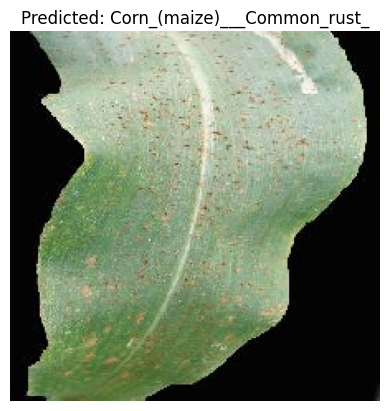

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


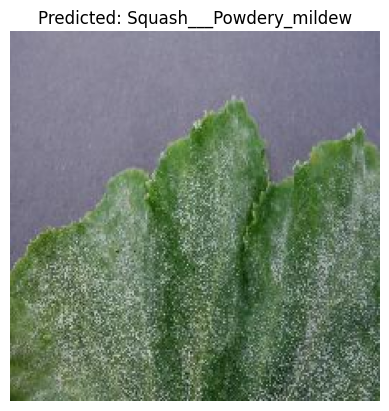

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


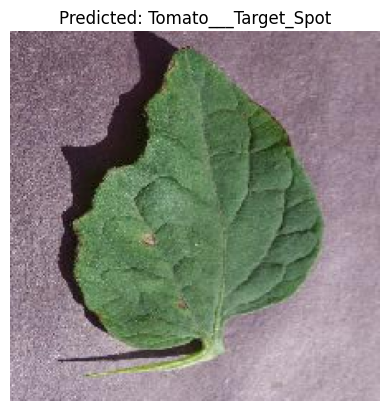

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


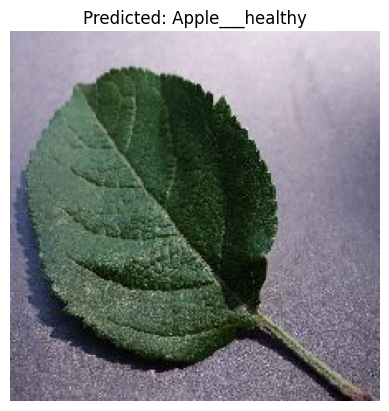

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


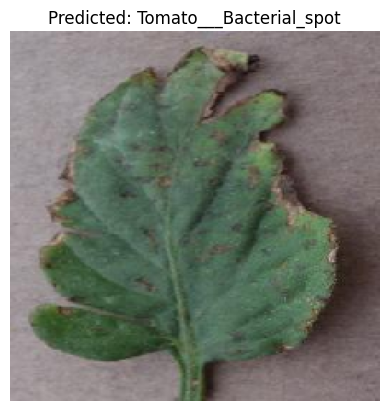

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


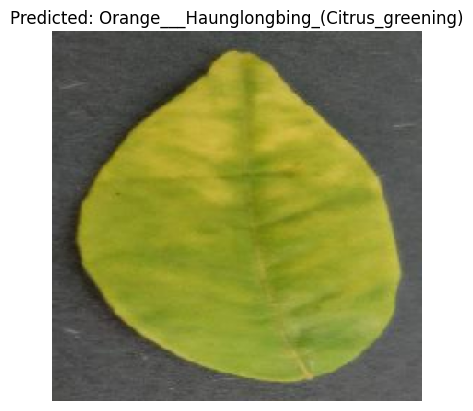

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


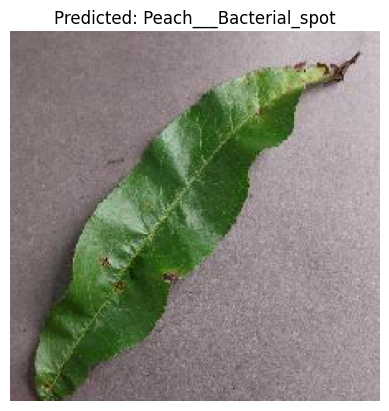

In [ ]:
import random
indices = random.sample(range(len(validation_generator.filenames)), 10)
for idx in indices:
    img_path = os.path.join(validation_generator.directory, validation_generator.filenames[idx])
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    pred = model.predict(np.expand_dims(img_array, axis=0))
    pred_class = class_names[np.argmax(pred)]
    plt.imshow(img)
    plt.title(f"Predicted: {pred_class}")
    plt.axis('off')
    plt.show()


Test model trên mẫu ngẫu nhiên từ merged_data

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import json

# Đường dẫn model và file mapping class
model_path = '/content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_15.h5'
mapping_path = '/content/class_indices_moi.json'

# Load model đã huấn luyện
model = load_model(model_path)

# Load ánh xạ index -> tên lớp
with open(mapping_path, 'r') as f:
    class_indices = json.load(f)
class_names = [class_indices[str(i)] for i in range(len(class_indices))]


Lấy mẫu ngẫu nhiên từ merged_data và dự đoán

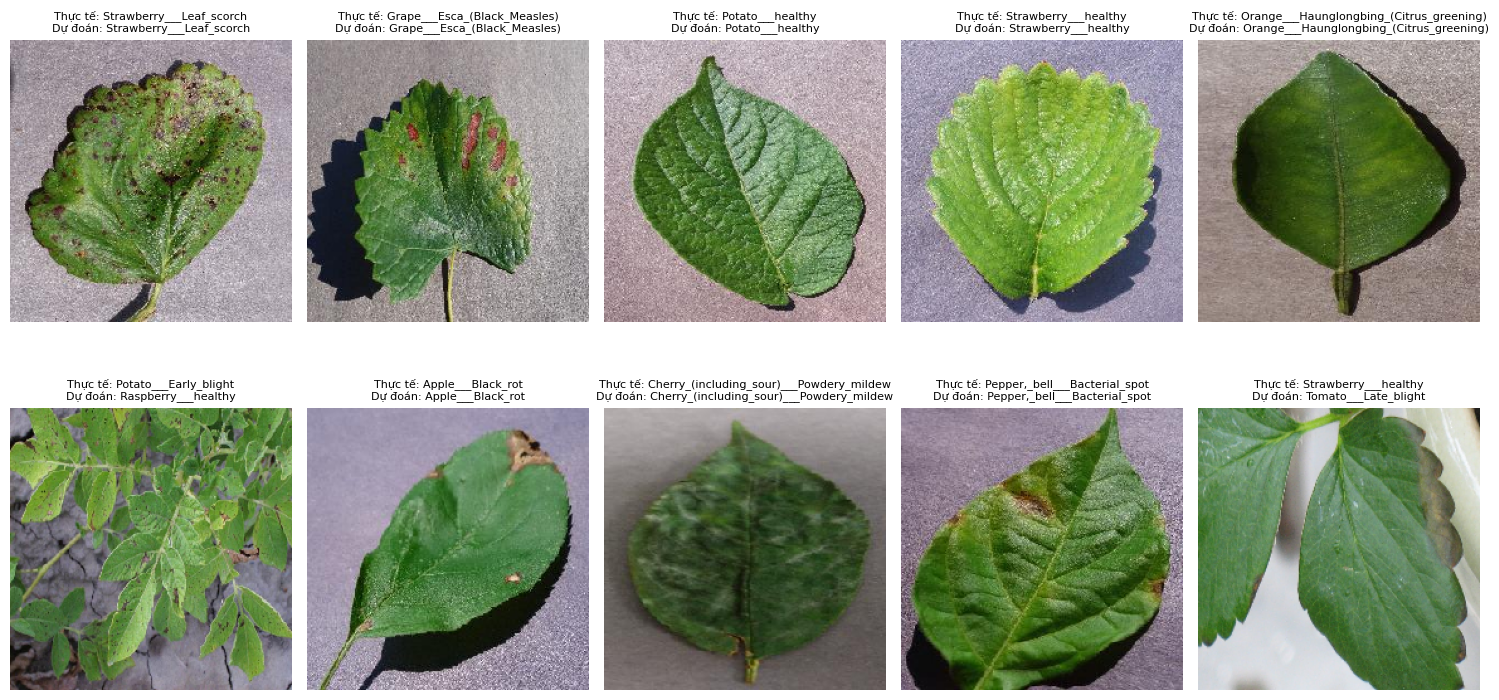

In [ ]:
IMG_SIZE = 224
data_dir = '/content/data/merged_dataset'
num_samples = 10  # Số lượng mẫu muốn test

# Lấy danh sách lớp
classes = os.listdir(data_dir)

# Lấy ngẫu nhiên ảnh từ các lớp
samples = []
for _ in range(num_samples):
    cls = random.choice(classes)
    cls_path = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    samples.append((img_path, cls))

# Dự đoán và hiển thị kết quả
plt.figure(figsize=(15, 8))
for i, (img_path, true_cls) in enumerate(samples):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    pred = model.predict(np.expand_dims(img_array, axis=0), verbose=0)
    pred_cls = class_names[np.argmax(pred)]
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f'Thực tế: {true_cls}\nDự đoán: {pred_cls}', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


Test model với ảnh hoàn toàn mới (upload thủ công)

Saving tải xuống (1).jfif to tải xuống (1) (1).jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


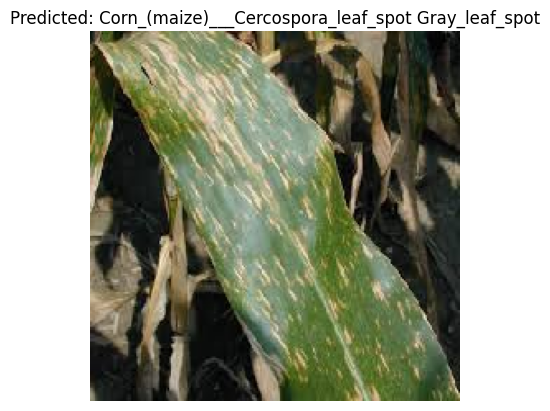

In [ ]:
from google.colab import files

uploaded = files.upload()  # Upload ảnh từ máy tính

for fn in uploaded.keys():
    img = load_img(fn, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    pred = model.predict(np.expand_dims(img_array, axis=0))
    pred_class = class_names[np.argmax(pred)]
    plt.imshow(img)
    plt.title(f"Predicted: {pred_class}")
    plt.axis('off')
    plt.show()


Xây giao diện FLask API để deploy model lên google cloud

In [ ]:
import pkg_resources

libraries = [
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'opencv-python',
    'tensorflow',
    'sklearn'
]

print("Versions of used libraries:")
for lib in libraries:
    try:
        version = pkg_resources.get_distribution(lib).version
        print(f"{lib}: {version}")
    except pkg_resources.DistributionNotFound:
        print(f"{lib}: Not installed")

Versions of used libraries:
numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
seaborn: 0.13.2
opencv-python: 4.11.0.86
tensorflow: 2.18.0
sklearn: Not installed


xây giao diện Flask API

Tạo cấu trúc thư mục dự án
  - app.py: Code Flask backend.

  - requirements.txt: Danh sách thư viện cần cài.

  - Procfile: Dùng cho Render/App Engine.

  - Dockerfile: Dùng cho Cloud Run.

  - saved_model/: Thư mục chứa model đã train.

  - templates/: Giao diện HTML.

  - static/: CSS, ảnh tĩnh.

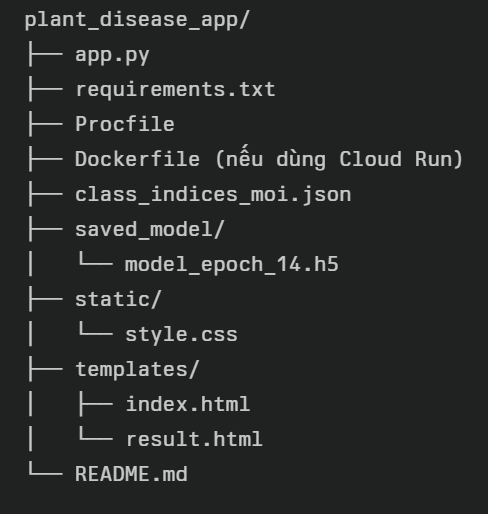

In [ ]:
# Tạo cấu trúc thư mục
!mkdir -p plant-disease-detector
!mkdir -p plant-disease-detector/templates
!mkdir -p plant-disease-detector/static/uploads
!mkdir -p plant-disease-detector/model

app.py

In [ ]:
# Tạo file app.py
%%writefile plant-disease-detector/app.py
import os
import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from flask import Flask, render_template, request, jsonify, redirect, url_for
from werkzeug.utils import secure_filename

app = Flask(__name__)
app.config['UPLOAD_FOLDER'] = 'static/uploads'
app.config['ALLOWED_EXTENSIONS'] = {'png', 'jpg', 'jpeg', 'gif'}
app.config['MAX_CONTENT_LENGTH'] = 16 * 1024 * 1024  # 16MB max upload

# Tạo thư mục uploads nếu chưa tồn tại
os.makedirs(app.config['UPLOAD_FOLDER'], exist_ok=True)

# Load model
MODEL_PATH = 'model/model_epoch_15 (1).h5'
model = load_model(MODEL_PATH)

# Load class mapping
with open('model/class_indices_moi.json', 'r') as f:
    class_indices = json.load(f)

# Tạo dictionary phân loại và thông tin bệnh
disease_info = {
    "Apple___Apple_scab": {
        "name": "Apple Scab",
        "description": "Bệnh đốm vảy trên táo do nấm Venturia inaequalis gây ra, xuất hiện các đốm nâu/xám trên lá và quả, làm giảm năng suất và chất lượng quả.",
        "treatment": "Cắt bỏ lá bệnh, phun thuốc gốc đồng hoặc thuốc chứa mancozeb, vệ sinh vườn cây."
    },
    "Apple___Cedar_apple_rust": {
        "name": "Apple Cedar Rust",
        "description": "Bệnh rỉ sắt táo cedar do nấm Gymnosporangium juniperi-virginianae gây ra, tạo đốm vàng cam trên lá táo.",
        "treatment": "Loại bỏ cây bách xanh hoặc tuyết tùng gần vườn táo, phun thuốc diệt nấm, thu gom và tiêu hủy lá bệnh."
    },
    "Apple___healthy": {
        "name": "Healthy Apple Leaf",
        "description": "Lá táo khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc thông thường và theo dõi sự phát triển của cây."
    },
}
# Đặt thông tin mặc định khi không tìm thấy thông tin bệnh
default_info = {
    "name": "Unknown Disease",
    "description": "Không có thông tin chi tiết về bệnh này.",
    "treatment": "Tham khảo ý kiến chuyên gia nông nghiệp."
}

def allowed_file(filename):
    return '.' in filename and filename.rsplit('.', 1)[1].lower() in app.config['ALLOWED_EXTENSIONS']

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def predict_disease(image_path):
    processed_image = preprocess_image(image_path)
    prediction = model.predict(processed_image)
    predicted_class_index = np.argmax(prediction[0])
    predicted_class_name = class_indices[str(predicted_class_index)]
    confidence = float(prediction[0][predicted_class_index])

    # Lấy thông tin bệnh
    info = disease_info.get(predicted_class_name, default_info)

    return {
        "class_name": predicted_class_name,
        "disease_name": info["name"],
        "description": info["description"],
        "treatment": info["treatment"],
        "confidence": confidence
    }

@app.route('/', methods=['GET', 'POST'])
def index():
    if request.method == 'POST':
        # Check if the post request has the file part
        if 'file' not in request.files:
            return redirect(request.url)

        file = request.files['file']

        # If user does not select file, browser also submits an empty part without filename
        if file.filename == '':
            return redirect(request.url)

        if file and allowed_file(file.filename):
            filename = secure_filename(file.filename)
            file_path = os.path.join(app.config['UPLOAD_FOLDER'], filename)
            file.save(file_path)

            # Predict disease
            result = predict_disease(file_path)

            return render_template('result.html',
                                  filename=filename,
                                  disease_name=result["disease_name"],
                                  class_name=result["class_name"],
                                  description=result["description"],
                                  treatment=result["treatment"],
                                  confidence=result["confidence"] * 100)

    return render_template('index.html')

@app.route('/analyze_webcam', methods=['POST'])
def analyze_webcam():
    # Đây là phần xử lý ảnh từ webcam, sẽ được implement sau
    if 'file' not in request.files:
        return jsonify({'error': 'No file part'})

    file = request.files['file']
    if file.filename == '':
        return jsonify({'error': 'No selected file'})

    if file and allowed_file(file.filename):
        filename = secure_filename(file.filename)
        file_path = os.path.join(app.config['UPLOAD_FOLDER'], filename)
        file.save(file_path)

        # Predict disease
        result = predict_disease(file_path)

        return jsonify(result)

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0')

Writing plant-disease-detector/app.py


Tạo file index.html

In [ ]:
%%writefile plant-disease-detector/templates/index.html
<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Nhận diện bệnh lá cây</title>
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.0.0/css/all.min.css">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0-alpha1/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        .leaf-icon {
            color: #4CAF50;
            margin-right: 10px;
        }
        .nav-tabs .nav-link {
            color: #495057;
        }
        .nav-tabs .nav-link.active {
            color: #4CAF50;
            font-weight: bold;
        }
        .upload-area {
            border: 2px dashed #ddd;
            border-radius: 5px;
            padding: 20px;
            text-align: center;
            margin: 20px 0;
            background-color: #f8f9fa;
        }
        .preview-img {
            max-width: 100%;
            max-height: 300px;
            margin: 10px auto;
        }
        .btn-detect {
            background-color: #4CAF50;
            color: white;
            margin-top: 10px;
        }
        .webcam-container {
            margin: 20px 0;
        }
        #video {
            width: 100%;
            max-width: 500px;
            border-radius: 5px;
            border: 1px solid #ddd;
        }
        #canvas {
            display: none;
        }
    </style>
</head>
<body>
    <div class="container py-4">
        <h1 class="text-center mb-4">
            <i class="fas fa-leaf leaf-icon"></i>Nhận diện bệnh lá cây
        </h1>

        <ul class="nav nav-tabs" id="myTab" role="tablist">
            <li class="nav-item" role="presentation">
                <button class="nav-link active" id="upload-tab" data-bs-toggle="tab" data-bs-target="#upload" type="button" role="tab" aria-controls="upload" aria-selected="true">
                    Tải ảnh lên
                </button>
            </li>
            <li class="nav-item" role="presentation">
                <button class="nav-link" id="webcam-tab" data-bs-toggle="tab" data-bs-target="#webcam" type="button" role="tab" aria-controls="webcam" aria-selected="false">
                    Chụp ảnh webcam
                </button>
            </li>
        </ul>

        <div class="tab-content" id="myTabContent">
            <!-- Upload Image Tab -->
            <div class="tab-pane fade show active" id="upload" role="tabpanel" aria-labelledby="upload-tab">
                <h5 class="mt-3">Chọn ảnh lá cây</h5>
                <form action="/" method="post" enctype="multipart/form-data" id="upload-form">
                    <div class="upload-area" id="drop-area">
                        <div class="mb-3">
                            <i class="fas fa-cloud-upload-alt fa-3x mb-3" style="color: #4CAF50;"></i>
                            <p>Drag and drop file here</p>
                            <p>Limit 200MB per file</p>
                            <div>
                                <label for="file-upload" class="btn btn-outline-secondary">Browse files</label>
                                <input type="file" id="file-upload" name="file" accept=".jpg,.jpeg,.png" style="display: none;" onchange="previewImage(this)">
                            </div>
                        </div>
                        <img id="preview" class="preview-img" style="display: none;">
                    </div>
                    <div class="text-center">
                        <button type="submit" class="btn btn-detect" id="detect-button" disabled>Phát hiện bệnh</button>
                    </div>
                </form>
            </div>

            <!-- Webcam Tab -->
            <div class="tab-pane fade" id="webcam" role="tabpanel" aria-labelledby="webcam-tab">
                <div class="webcam-container text-center">
                    <h5 class="mt-3 mb-3">Chụp ảnh từ webcam</h5>
                    <div>
                        <video id="video" autoplay></video>
                        <canvas id="canvas"></canvas>
                    </div>
                    <div class="mt-3">
                        <button id="startCamera" class="btn btn-outline-secondary me-2">Start Camera</button>
                        <button id="takePhoto" class="btn btn-primary me-2" disabled>Take Photo</button>
                        <button id="analyzePhoto" class="btn btn-detect" disabled>Phát hiện bệnh</button>
                    </div>
                    <div id="webcam-result" class="mt-4"></div>
                </div>
            </div>
        </div>
    </div>

    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0-alpha1/dist/js/bootstrap.bundle.min.js"></script>
    <script>
        // File preview functionality
        function previewImage(input) {
            const preview = document.getElementById('preview');
            const detectButton = document.getElementById('detect-button');

            if (input.files && input.files[0]) {
                const reader = new FileReader();

                reader.onload = function(e) {
                    preview.src = e.target.result;
                    preview.style.display = 'block';
                    detectButton.disabled = false;
                }

                reader.readAsDataURL(input.files[0]);
            } else {
                preview.style.display = 'none';
                detectButton.disabled = true;
            }
        }

        // Drag and drop functionality
        const dropArea = document.getElementById('drop-area');
        const fileUpload = document.getElementById('file-upload');

        ['dragenter', 'dragover', 'dragleave', 'drop'].forEach(eventName => {
            dropArea.addEventListener(eventName, preventDefaults, false);
        });

        function preventDefaults(e) {
            e.preventDefault();
            e.stopPropagation();
        }

        ['dragenter', 'dragover'].forEach(eventName => {
            dropArea.addEventListener(eventName, highlight, false);
        });

        ['dragleave', 'drop'].forEach(eventName => {
            dropArea.addEventListener(eventName, unhighlight, false);
        });

        function highlight() {
            dropArea.style.borderColor = '#4CAF50';
            dropArea.style.backgroundColor = '#f0f8f0';
        }

        function unhighlight() {
            dropArea.style.borderColor = '#ddd';
            dropArea.style.backgroundColor = '#f8f9fa';
        }

        dropArea.addEventListener('drop', handleDrop, false);

        function handleDrop(e) {
            const dt = e.dataTransfer;
            const files = dt.files;

            if (files.length) {
                fileUpload.files = files;
                previewImage(fileUpload);
            }
        }

        // Webcam functionality
        const video = document.getElementById('video');
        const canvas = document.getElementById('canvas');
        const startButton = document.getElementById('startCamera');
        const takePhotoButton = document.getElementById('takePhoto');
        const analyzeButton = document.getElementById('analyzePhoto');
        const webcamResult = document.getElementById('webcam-result');
        let stream = null;

        startButton.addEventListener('click', async () => {
            try {
                stream = await navigator.mediaDevices.getUserMedia({ video: true });
                video.srcObject = stream;
                startButton.disabled = true;
                takePhotoButton.disabled = false;
            } catch (err) {
                console.error('Error accessing camera:', err);
                alert('Could not access camera. Please make sure you have granted permission.');
            }
        });

        takePhotoButton.addEventListener('click', () => {
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            const ctx = canvas.getContext('2d');
            ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
            analyzeButton.disabled = false;
        });

        analyzeButton.addEventListener('click', () => {
            canvas.toBlob(blob => {
                const formData = new FormData();
                formData.append('file', blob, 'webcam.jpg');

                fetch('/analyze_webcam', {
                    method: 'POST',
                    body: formData
                })
                .then(response => response.json())
                .then(data => {
                    // Display result
                    webcamResult.innerHTML = `
                        <div class="alert alert-success">
                            <h4>${data.disease_name}</h4>
                            <p><strong>Mô tả:</strong> ${data.description}</p>
                            <p><strong>Cách chữa trị:</strong> ${data.treatment}</p>
                            <p><strong>Độ tin cậy:</strong> ${(data.confidence * 100).toFixed(2)}%</p>
                        </div>
                    `;

                    // Stop the camera stream
                    if (stream) {
                        stream.getTracks().forEach(track => track.stop());
                        video.srcObject = null;
                        startButton.disabled = false;
                        takePhotoButton.disabled = true;
                    }
                })
                .catch(error => {
                    console.error('Error analyzing image:', error);
                    webcamResult.innerHTML = `<div class="alert alert-danger">Có lỗi xảy ra khi phân tích ảnh.</div>`;
                });
            }, 'image/jpeg', 0.95);
        });

        // Tab switching
        document.getElementById('webcam-tab').addEventListener('click', () => {
            if (stream) {
                stream.getTracks().forEach(track => track.stop());
                video.srcObject = null;
            }
            startButton.disabled = false;
            takePhotoButton.disabled = true;
            analyzeButton.disabled = true;
        });
    </script>
</body>
</html>

Writing plant-disease-detector/templates/index.html


Tạo file result.html

In [ ]:
%%writefile plant-disease-detector/templates/result.html
<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Kết quả phân tích bệnh lá cây</title>
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.0.0/css/all.min.css">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0-alpha1/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        .leaf-icon {
            color: #4CAF50;
            margin-right: 10px;
        }
        .result-container {
            background-color: #f8fff8;
            border-radius: 10px;
            padding: 20px;
            margin: 20px 0;
            border: 1px solid #e0e0e0;
        }
        .result-image {
            max-width: 100%;
            max-height: 300px;
            border-radius: 5px;
            border: 1px solid #ddd;
        }
        .disease-name {
            color: #d9534f;
            font-weight: bold;
            margin-top: 10px;
        }
        .confidence-bar {
            height: 25px;
            background-color: #e9ecef;
            border-radius: 5px;
            margin: 10px 0;
        }
        .confidence-fill {
            height: 100%;
            background-color: #4CAF50;
            border-radius: 5px;
            text-align: center;
            color: white;
            font-weight: bold;
            line-height: 25px;
        }
        .info-box {
            background-color: #f8f9fa;
            border-left: 5px solid #4CAF50;
            padding: 15px;
            margin-top: 15px;
        }
        .back-button {
            background-color: #4CAF50;
            color: white;
        }
    </style>
</head>
<body>
    <div class="container py-4">
        <h1 class="text-center mb-4">
            <i class="fas fa-leaf leaf-icon"></i>Kết quả phân tích
        </h1>

        <div class="result-container">
            <div class="row">
                <div class="col-md-6 text-center">
                    <img src="{{ url_for('static', filename='uploads/' + filename) }}" alt="Plant Leaf" class="result-image">
                    <h4 class="disease-name">{{ disease_name }}</h4>
                    <div class="mt-2">Độ tin cậy:</div>
                    <div class="confidence-bar">
                        <div class="confidence-fill" style="width: {{ confidence }}%">
                            {{ "%.2f"|format(confidence) }}%
                        </div>
                    </div>
                </div>
                <div class="col-md-6">
                    <div class="info-box">
                        <h5>Mô tả:</h5>
                        <p>{{ description }}</p>

                        <h5 class="mt-3">Cách chữa trị:</h5>
                        <p>{{ treatment }}</p>
                    </div>
                </div>
            </div>
        </div>

        <div class="text-center mt-4">
            <a href="/" class="btn back-button">
                <i class="fas fa-arrow-left"></i> Quay lại
            </a>
        </div>
    </div>

    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0-alpha1/dist/js/bootstrap.bundle.min.js"></script>
</body>
</html>

Writing plant-disease-detector/templates/result.html


tạo file requirements.txt

In [ ]:
!pip install Flask Pillow gunicorn

In [ ]:
import pkg_resources

libraries = [
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'opencv-python',
    'tensorflow',
    'sklearn'
]

print("Versions of used libraries:")
for lib in libraries:
    try:
        version = pkg_resources.get_distribution(lib).version
        print(f"{lib}: {version}")
    except pkg_resources.DistributionNotFound:
        print(f"{lib}: Not installed")

Versions of used libraries:
numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
seaborn: 0.13.2
opencv-python: 4.11.0.86
tensorflow: 2.18.0
sklearn: Not installed


In [ ]:
%%writefile plant-disease-detector/requirements.txt
numpy==2.0.2
pandas==2.2.2
#matplotlib==3.10.0
#seaborn==0.13.2
opencv-python==4.11.0.86
tensorflow==2.18.0
Flask==3.1.1
Pillow==11.2.1
gunicorn==23.0.0
Werkzeug==2.2.3

Writing plant-disease-detector/requirements.txt


này của claude

In [ ]:
%%writefile plant-disease-detector/requirements.txt
Flask==2.2.3
numpy==1.23.5
tensorflow==2.12.0
Pillow==9.4.0
Werkzeug==2.2.3

Tải file model và class indices từ google drive

In [ ]:
# Tạo thư mục model nếu chưa tồn tại
!mkdir -p plant-disease-detector/model

# Tải file model từ Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Copy file model.h5 từ Google Drive
!cp /content/drive/MyDrive/PlantDiseaseModel_moi/model_epoch_15.h5 plant-disease-detector/model/

# Copy file class indices từ Google Drive
!cp /content/drive/MyDrive/PlantDiseaseModel_moi/class_indices_moi.json plant-disease-detector/model/class_indices.json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Tạo file README.md

In [ ]:
%%writefile plant-disease-detector/README.md
# Ứng dụng nhận diện bệnh lá cây

Đây là một ứng dụng web sử dụng Flask và mô hình học máy để nhận diện bệnh trên lá cây thông qua hình ảnh.

## Tính năng

- Tải lên hình ảnh lá cây để phân tích
- Chụp ảnh trực tiếp từ webcam
- Chuẩn bị tích hợp với camera ESP32 (chưa kích hoạt)
- Hiển thị kết quả phân tích với thông tin chi tiết về bệnh và cách điều trị
-> Chạy app.py

Writing plant-disease-detector/README.md


Đẩy code lên GitHub từ google colab luôn

In [ ]:
!apt-get install git


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.12).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


cấu hình Git với tài khoản

In [ ]:
!git config --global user.email "nhule130504@gmail.com"
!git config --global user.name "paparoti1305"


Khởi tạo Git repo trong thư mục dự án

In [ ]:
%cd /content/plant-disease-detector
!git init


/content/plant-disease-detector
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/plant-disease-detector/.git/


Kết nối với GitHub (add remote)

In [ ]:
!git remote add origin https://github.com/paparoti1305/plant-disease-detector.git


Thêm toàn bộ file vào git và commit

In [ ]:
!git add .
!git commit -m "Initial commit: Plant disease detector Flask app"


[master (root-commit) 7ef3f80] Initial commit: Plant disease detector Flask app
 9 files changed, 592 insertions(+)
 create mode 100644 README.md
 create mode 100644 app.py
 create mode 100644 model/class_indices.json
 create mode 100644 model/class_indices_moi.json
 create mode 100644 model/model_epoch_15 (1).h5
 create mode 100644 model/model_epoch_15.h5
 create mode 100644 requirements.txt
 create mode 100644 templates/index.html
 create mode 100644 templates/result.html


Đẩy code lên github

In [ ]:
import os
import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from flask import Flask, render_template, request, jsonify, redirect, url_for
from werkzeug.utils import secure_filename

app = Flask(__name__)
app.config['UPLOAD_FOLDER'] = 'static/uploads'
app.config['ALLOWED_EXTENSIONS'] = {'png', 'jpg', 'jpeg', 'gif'}
app.config['MAX_CONTENT_LENGTH'] = 16 * 1024 * 1024  # 16MB max upload

# Tạo thư mục uploads nếu chưa tồn tại
os.makedirs(app.config['UPLOAD_FOLDER'], exist_ok=True)

# Load model
MODEL_PATH = 'model/model_epoch_15 (1).h5'
model = load_model(MODEL_PATH)

# Load class mapping
with open('model/class_indices_moi.json', 'r') as f:
    class_indices = json.load(f)

# Tạo dictionary phân loại và thông tin bệnh
disease_info = {
    "Apple___Apple_scab": {
        "name": "Apple Scab",
        "desc": "Bệnh đốm vảy trên táo do nấm Venturia inaequalis gây ra, xuất hiện các đốm nâu/xám trên lá và quả, làm giảm năng suất và chất lượng quả.",
        "treatment": "Cắt bỏ lá bệnh, phun thuốc gốc đồng hoặc thuốc chứa mancozeb, vệ sinh vườn cây."
    },
    "Apple___Cedar_apple_rust": {
        "name": "Apple Rust",
        "desc": "Bệnh gỉ sắt trên táo, gây ra các đốm màu cam trên lá, có thể làm rụng lá sớm và ảnh hưởng đến sự phát triển của cây.",
        "treatment": "Loại bỏ lá bệnh, dùng thuốc diệt nấm (như mancozeb, myclobutanil), trồng giống kháng bệnh."
    },
    "Apple___healthy": {
        "name": "Apple Healthy",
        "desc": "Lá táo khỏe mạnh, không có dấu hiệu bệnh lý.",
        "treatment": "Không có bệnh, tiếp tục chăm sóc tốt, bón phân hợp lý và tưới nước đầy đủ."
    },
    "Pepper,_bell___healthy": {
        "name": "Bell Pepper Healthy",
        "desc": "Lá ớt chuông khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc, kiểm tra định kỳ để phát hiện bệnh sớm."
    },
    "Pepper,_bell___Bacterial_spot": {
        "name": "Bell Pepper Bacterial Spot",
        "desc": "Bệnh đốm vi khuẩn trên ớt chuông, gây ra các đốm nâu, lõm trên lá và quả, có thể làm rụng lá.",
        "treatment": "Loại bỏ lá bệnh, phun thuốc gốc đồng, luân canh cây trồng, sử dụng giống kháng bệnh."
    },
    "Blueberry___healthy": {
        "name": "Blueberry Healthy",
        "desc": "Lá việt quất khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc, tưới nước và bón phân hợp lý."
    },
    "Cherry_(including_sour)___healthy": {
        "name": "Cherry Healthy",
        "desc": "Lá anh đào khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc, kiểm tra định kỳ."
    },
    "Corn_(maize)___Common_rust_": {
        "name": "Corn Common Rust",
        "desc": "Bệnh gỉ sắt thông thường trên ngô, xuất hiện các đốm màu nâu đỏ trên lá, làm giảm năng suất.",
        "treatment": "Sử dụng giống kháng bệnh, phun thuốc trừ nấm (như mancozeb, azoxystrobin) khi phát hiện bệnh."
    },
    "Corn_(maize)___Northern_Leaf_Blight": {
        "name": "Corn Northern Leaf Blight",
        "desc": "Bệnh cháy lá phương Bắc trên ngô, gây ra các vết dài màu xám trên lá, làm giảm khả năng quang hợp.",
        "treatment": "Trồng giống kháng bệnh, luân canh cây trồng, phun thuốc trừ nấm khi cần thiết."
    },
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": {
        "name": "Corn Gray Leaf Spot",
        "desc": "Bệnh đốm xám lá ngô do nấm Cercospora gây ra, xuất hiện các vết xám hình chữ nhật trên lá.",
        "treatment": "Sử dụng giống kháng bệnh, phun thuốc trừ nấm, vệ sinh tàn dư thực vật."
    },
    "Peach___healthy": {
        "name": "Peach Healthy",
        "desc": "Lá đào khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc, kiểm tra định kỳ."
    },
    "Potato___Early_blight": {
        "name": "Potato Early Blight",
        "desc": "Bệnh sớm trên khoai tây do nấm Alternaria solani, gây ra các đốm tròn nâu trên lá, có quầng vàng.",
        "treatment": "Cắt bỏ lá bệnh, phun thuốc trừ nấm (như mancozeb, chlorothalonil), luân canh cây trồng."
    },
    "Potato___Late_blight": {
        "name": "Potato Late Blight",
        "desc": "Bệnh mốc sương trên khoai tây do nấm Phytophthora infestans, gây thối lá, thân và củ.",
        "treatment": "Phun thuốc trừ nấm (như metalaxyl, cymoxanil), tiêu hủy cây bệnh, trồng giống kháng bệnh."
    },
    "Raspberry___healthy": {
        "name": "Raspberry Healthy",
        "desc": "Lá mâm xôi khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc, kiểm tra định kỳ."
    },
    "Soybean___healthy": {
        "name": "Soybean Healthy",
        "desc": "Lá đậu tương khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc, kiểm tra định kỳ."
    },
    "Squash___Powdery_mildew": {
        "name": "Squash Powdery Mildew",
        "desc": "Bệnh phấn trắng trên bí, xuất hiện lớp phấn trắng trên bề mặt lá, làm lá vàng và khô.",
        "treatment": "Cắt bỏ lá bệnh, phun thuốc trừ nấm (như sulfur, myclobutanil), tăng thông thoáng cho cây."
    },
    "Strawberry___healthy": {
        "name": "Strawberry Healthy",
        "desc": "Lá dâu tây khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc, kiểm tra định kỳ."
    },
    "Tomato___Early_blight": {
        "name": "Tomato Early Blight",
        "desc": "Bệnh sớm trên cà chua do nấm Alternaria solani, gây đốm nâu tròn trên lá, thân và quả.",
        "treatment": "Cắt bỏ lá bệnh, phun thuốc trừ nấm (như mancozeb, chlorothalonil), luân canh cây trồng."
    },
    "Tomato___Septoria_leaf_spot": {
        "name": "Tomato Septoria Leaf Spot",
        "desc": "Bệnh đốm lá Septoria trên cà chua, xuất hiện các đốm nhỏ màu nâu xám trên lá.",
        "treatment": "Cắt bỏ lá bệnh, phun thuốc trừ nấm (như mancozeb, copper), vệ sinh vườn."
    },
    "Tomato___healthy": {
        "name": "Tomato Healthy",
        "desc": "Lá cà chua khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc, kiểm tra định kỳ."
    },
    "Tomato___Bacterial_spot": {
        "name": "Tomato Bacterial Spot",
        "desc": "Bệnh đốm vi khuẩn trên cà chua, gây đốm nhỏ màu nâu đen trên lá, thân và quả.",
        "treatment": "Loại bỏ lá bệnh, phun thuốc gốc đồng, sử dụng giống kháng bệnh."
    },
    "Tomato___Late_blight": {
        "name": "Tomato Late Blight",
        "desc": "Bệnh mốc sương trên cà chua do nấm Phytophthora infestans, gây thối lá, thân và quả.",
        "treatment": "Phun thuốc trừ nấm (như metalaxyl, cymoxanil), tiêu hủy cây bệnh, trồng giống kháng bệnh."
    },
    "Tomato___Tomato_mosaic_virus": {
        "name": "Tomato Mosaic Virus",
        "desc": "Bệnh virus khảm trên cà chua, gây lá biến dạng, vàng, giảm năng suất.",
        "treatment": "Tiêu hủy cây bệnh, vệ sinh dụng cụ, sử dụng giống kháng virus."
    },
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": {
        "name": "Tomato Yellow Leaf Curl Virus",
        "desc": "Bệnh virus vàng xoăn lá trên cà chua, làm lá xoăn, vàng, cây còi cọc.",
        "treatment": "Tiêu hủy cây bệnh, kiểm soát bọ phấn, sử dụng giống kháng virus."
    },
    "Tomato___Leaf_Mold": {
        "name": "Tomato Leaf Mold",
        "desc": "Bệnh mốc lá trên cà chua, xuất hiện các mảng vàng ở mặt trên lá, mặt dưới có lớp mốc màu ô liu.",
        "treatment": "Cắt bỏ lá bệnh, tăng thông thoáng, phun thuốc trừ nấm (như mancozeb, copper)."
    },
    "Grape___healthy": {
        "name": "Grape Healthy",
        "desc": "Lá nho khỏe mạnh, không có dấu hiệu bệnh.",
        "treatment": "Tiếp tục chăm sóc, kiểm tra định kỳ."
    },
    "Grape___Black_rot": {
        "name": "Grape Black Rot",
        "desc": "Bệnh thối đen trên nho do nấm Guignardia bidwellii, gây đốm đen trên lá, quả bị thối đen.",
        "treatment": "Cắt bỏ lá và quả bệnh, phun thuốc trừ nấm (như mancozeb, myclobutanil), vệ sinh vườn."
    }
}
# Đặt thông tin mặc định khi không tìm thấy thông tin bệnh
default_info = {
    "name": "Unknown Disease",
    "description": "Không có thông tin chi tiết về bệnh này.",
    "treatment": "Tham khảo ý kiến chuyên gia nông nghiệp."
}

def allowed_file(filename):
    return '.' in filename and filename.rsplit('.', 1)[1].lower() in app.config['ALLOWED_EXTENSIONS']

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def predict_disease(image_path):
    processed_image = preprocess_image(image_path)
    prediction = model.predict(processed_image)
    predicted_class_index = np.argmax(prediction[0])
    predicted_class_name = class_indices[str(predicted_class_index)]
    confidence = float(prediction[0][predicted_class_index])

    # Lấy thông tin bệnh
    info = disease_info.get(predicted_class_name, default_info)

    return {
        "class_name": predicted_class_name,
        "disease_name": info["name"],
        "description": info["description"],
        "treatment": info["treatment"],
        "confidence": confidence
    }

@app.route('/', methods=['GET', 'POST'])
def index():
    if request.method == 'POST':

        if 'file' not in request.files:
            return redirect(request.url)

        file = request.files['file']


        if file.filename == '':
            return redirect(request.url)

        if file and allowed_file(file.filename):
            filename = secure_filename(file.filename)
            file_path = os.path.join(app.config['UPLOAD_FOLDER'], filename)
            file.save(file_path)

            # Predict disease
            result = predict_disease(file_path)

            return render_template('result.html',
                                  filename=filename,
                                  disease_name=result["disease_name"],
                                  class_name=result["class_name"],
                                  description=result["description"],
                                  treatment=result["treatment"],
                                  confidence=result["confidence"] * 100)

    return render_template('index.html')

@app.route('/analyze_webcam', methods=['POST'])
def analyze_webcam():
    # Đây là phần xử lý ảnh từ webcam, sẽ được implement sau
    if 'file' not in request.files:
        return jsonify({'error': 'No file part'})

    file = request.files['file']
    if file.filename == '':
        return jsonify({'error': 'No selected file'})

    if file and allowed_file(file.filename):
        filename = secure_filename(file.filename)
        file_path = os.path.join(app.config['UPLOAD_FOLDER'], filename)
        file.save(file_path)

        # Predict disease
        result = predict_disease(file_path)

        return jsonify(result)

# @app.route('/analyze_esp32', methods=['POST'])
# def analyze_esp32():
#     # Phần này dành cho ESP32 camera, sẽ được implement sau khi cần
#     pass

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0')


In [ ]:
!git push https://paparoti1305:@github.com/paparoti1305/plant-disease-detector.git main


Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (11/11), done.
Writing objects: 100% (11/11), 15.87 MiB | 6.36 MiB/s, done.
Total 11 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), done.
To https://github.com/paparoti1305/plant-disease-detector.git
 * [new branch]      main -> main


Tạo Dockerfile

In [ ]:
%%writefile /content/plant-disease-detector/Dockerfile
# Sử dụng image python chính thức
FROM python:3.10-slim

# Cài đặt các thư viện hệ thống cần thiết
RUN apt-get update && apt-get install -y --no-install-recommends \
    build-essential \
    && rm -rf /var/lib/apt/lists/*

# Tạo thư mục app
WORKDIR /app

# Copy toàn bộ code vào container
COPY . /app

# Cài đặt các thư viện Python
RUN pip install --upgrade pip
RUN pip install --no-cache-dir -r requirements.txt

# Expose port 8080 (Cloud Run mặc định dùng 8080)
EXPOSE 8080

# Biến môi trường cho Flask
ENV PORT=8080
ENV FLASK_ENV=production

# Chạy app với gunicorn
CMD exec gunicorn --bind :8080 --workers 1 --threads 8 app:app


Writing /content/plant-disease-detector/Dockerfile


In [ ]:
!cat /content/plant-disease-detector/Dockerfile


# Sử dụng image python chính thức
FROM python:3.10-slim

# Cài đặt các thư viện hệ thống cần thiết
RUN apt-get update && apt-get install -y --no-install-recommends \
    build-essential \
    && rm -rf /var/lib/apt/lists/*

# Tạo thư mục app
WORKDIR /app

# Copy toàn bộ code vào container
COPY . /app

# Cài đặt các thư viện Python
RUN pip install --upgrade pip
RUN pip install --no-cache-dir -r requirements.txt

# Expose port 8080 (Cloud Run mặc định dùng 8080)
EXPOSE 8080

# Biến môi trường cho Flask
ENV PORT=8080
ENV FLASK_ENV=production

# Chạy app với gunicorn
CMD exec gunicorn --bind :8080 --workers 1 --threads 8 app:app


Thêm Dockerfile vào Git và push lên GitHub

In [ ]:
%cd /content/plant-disease-detector
!git add Dockerfile
!git commit -m "Add Dockerfile for Cloud Run deployment"
!git push https://paparoti1305:@github.com/paparoti1305/plant-disease-detector.git main



/content/plant-disease-detector
On branch main
nothing to commit, working tree clean
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 773 bytes | 773.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/paparoti1305/plant-disease-detector.git
   7ef3f80..f3fe1c3  main -> main


XONG

In [ ]:
# Cài đặt git nếu cần
!apt-get install -y git

# Khởi tạo git repository
%cd plant-disease-detector
!git init
!git add .
!git config --global user.email "your-email@example.com"
!git config --global user.name "Your Name"
!git commit -m "Initial commit"

# Kết nối với GitHub repository
!git remote add origin https://github.com/YOUR-USERNAME/plant-disease-detection.git

# Đẩy code lên GitHub
# Sử dụng Personal Access Token thay vì mật khẩu
!git push -u origin master

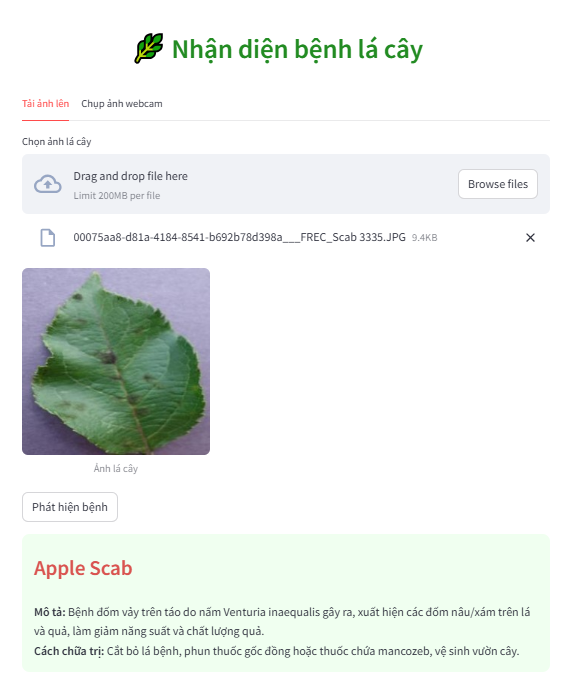